<a href="https://colab.research.google.com/github/QuintroCristian/CristianDiv/blob/main/Ejercicio_Segmentaci%C3%B3n_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

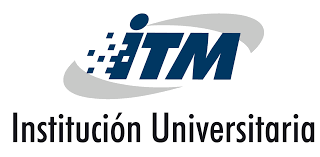

#ITM - Institución Universitaria
#Tema: Machine learning - Aprendizaje NO supervisado
#Juan Carlos Briñez de León

#0. Introducción (Algoritmo K-means)

El aprendizaje no supervisado en inteligencia artificial es un tipo de aprendizaje automático donde los algoritmos analizan datos sin etiquetas ni supervisión humana, buscando patrones y relaciones inherentes en la información.

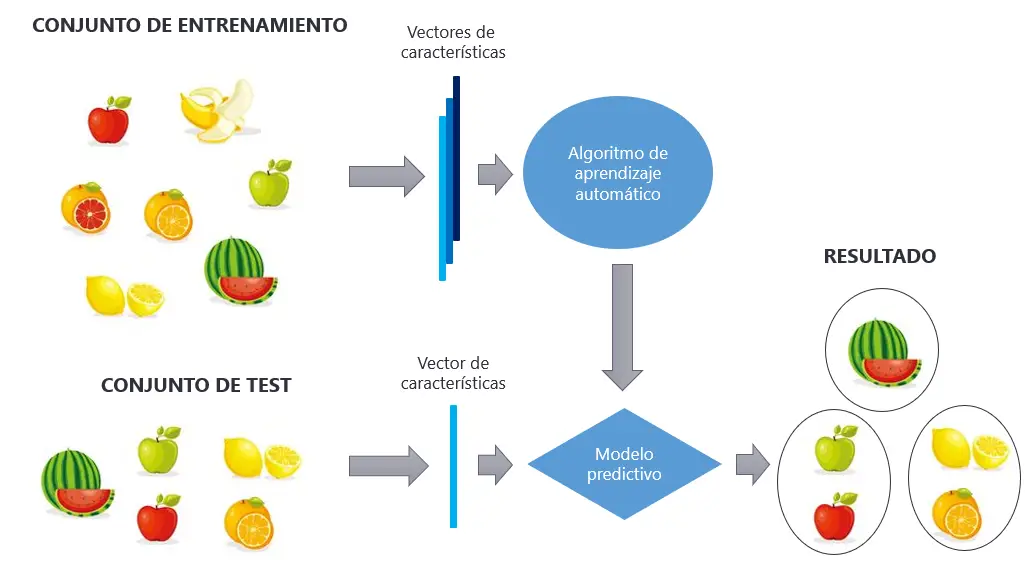

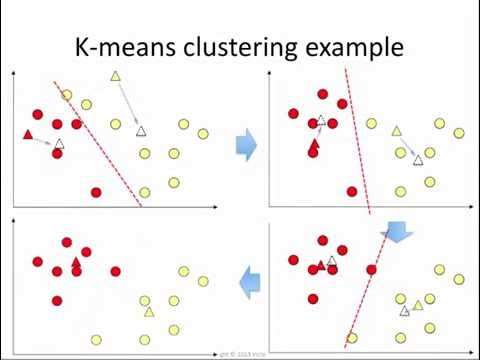

In [1]:
# Cargando datos
from google.colab import files # Librería para activar uso del directorio
import pandas as pd
import numpy as np #Librería para manejo matricial de los datos
import time #Librería para incluir pausas
import matplotlib.pyplot as plt #Librería para gráficos
from google.colab import output #Librería para manipular la ventana de resultados

# Cargar una archivo desde tu dispositivo local
Cargador = files.upload()

# Leer archivo con Pandas
for Nombre in Cargador.keys():
    #Mis_datos = pd.read_csv(Nombre,sep=',')
    dataset = pd.read_csv(Nombre,sep=',')

display(dataset)
time.sleep(5)
output.clear()
print('Dataset cargado correctamente!!')

Dataset cargado correctamente!!


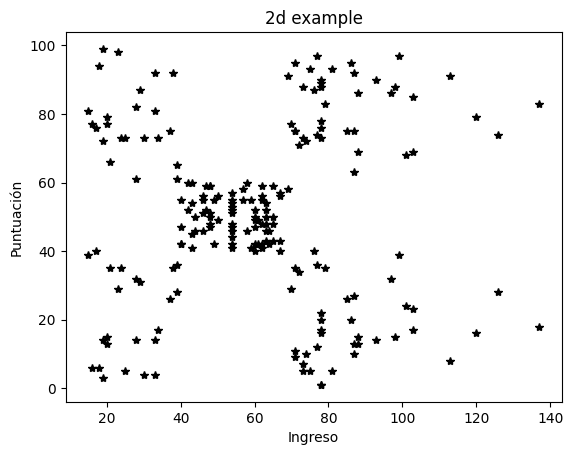

In [6]:
X = dataset.iloc[:, [3, 4]].values
plt.plot(X[:,0],X[:,1],'*k')
plt.xlabel('Ingreso')
plt.ylabel('Puntuación')
plt.title('2d example')
plt.show()

==============================================================

In [7]:
# Ingresando el número de conjuntos deseados
k=int(input('Ingrese el número de conjuntos deseados: '))

Ingrese el número de conjuntos deseados: 4


===============================================================

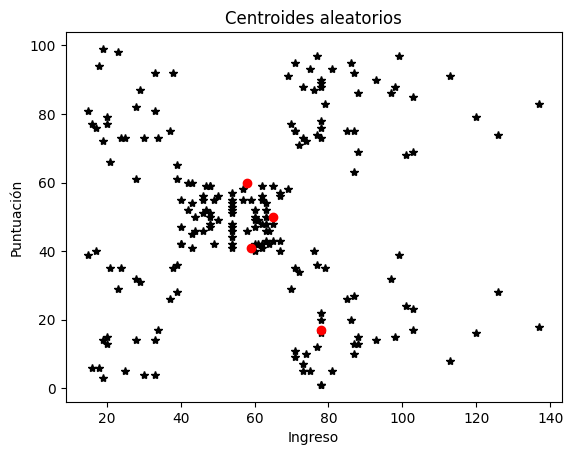

In [8]:
#Generación de centroides
import random #Librería para generar números aleatorios
[Fl,Cl]=X.shape
Centroides=np.zeros((k,Cl))
for i in range(k):
  Centroides[i,:]=X[random.randint(0, Fl),:]
#Graficando datos y centroides iniciales
print('')
plt.plot(X[:,0],X[:,1],'*k')
plt.plot(Centroides[:,0],Centroides[:,1],'or')
plt.xlabel('Ingreso')
plt.ylabel('Puntuación')
plt.title('Centroides aleatorios')
plt.show()

===============================================================

Para la distancia euclidiana: https://www.delftstack.com/es/howto/numpy/calculate-euclidean-distance/

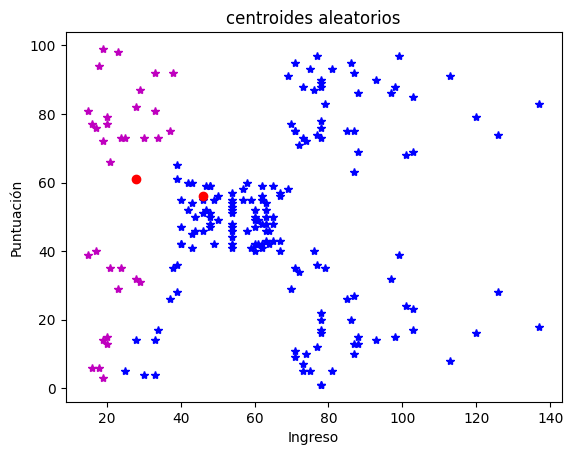

In [ ]:
#Agrupando datos según las distancias de cada punto a cada uno de los centroides
from math import sqrt #Librería para raíz cuadrada
Distancias_Centroides=np.zeros((1,k))
Etiquetas=np.zeros((Fl,1))
for i in range(Fl):
  for j in range(k):
    Distancias_Centroides[0,j]=np.sqrt(np.sum(np.square(X[i,:]-Centroides[j,:])))
  Pos=np.argmin(Distancias_Centroides[0,0:k])
  Etiquetas[i,0]=Pos

#Graficando los puntos con colores según etiquetas
Color=["*m","*b","*y","*g","*k","*c","*w"]
for i in range(Fl):
  for j in range(k):
    if Etiquetas[i,0]==j:
      plt.plot(X[i,0],X[i,1],Color[j])

plt.plot(Centroides[:,0],Centroides[:,1],'or')
plt.xlabel('Ingreso')
plt.ylabel('Puntuación')
plt.title('centroides aleatorios')
plt.show()

===============================================================


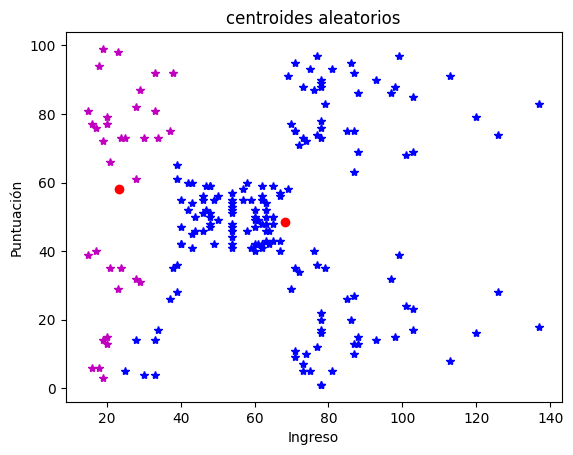

In [ ]:
#Modificando centroides
for i in range(k):
  suma=np.zeros((1,Cl))
  cont=0
  for j in range (Fl):
      if Etiquetas[j,0]==i:
        cont=cont+1
        suma=suma+X[j,:]

  Centroides[i,:]=suma[0,:]/cont

#Graficando los puntos con colores según etiquetas
Color=["*m","*b","*y","*g","*k","*c","*w"]
for i in range(Fl):
  for j in range(k):
    if Etiquetas[i,0]==j:
      plt.plot(X[i,0],X[i,1],Color[j])

plt.plot(Centroides[:,0],Centroides[:,1],'or')
plt.xlabel('Ingreso')
plt.ylabel('Puntuación')
plt.title('centroides aleatorios')
plt.show()

===============================================================

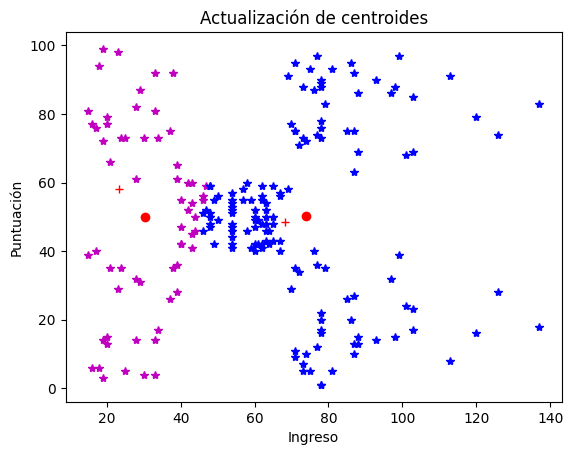

In [ ]:
#Repetir el proceso: Asigno etiquetas, grafico y actualizo centroides

#1. Etiqueto según distancias a centroides
from math import sqrt
Distancias_Centroides=np.zeros((1,k))
Etiquetas=np.zeros((Fl,1))
for i in range(Fl):
  for j in range(k):
    Distancias_Centroides[0,j]=np.sqrt(np.sum(np.square(X[i,:]-Centroides[j,:])))
  Pos=np.argmin(Distancias_Centroides[0,0:k])
  Etiquetas[i,0]=Pos

#2. Graficando los puntos con colores según etiquetas
Color=["*m","*b","*y","*g","*k","*c","*w"]
for i in range(Fl):
  for j in range(k):
    if Etiquetas[i,0]==j:
      plt.plot(X[i,0],X[i,1],Color[j])

plt.plot(Centroides[:,0],Centroides[:,1],'+r')
plt.xlabel('Ingreso')
plt.ylabel('Puntuación')
plt.title('Actualización de centroides')

#3. Actualizo centroide
for i in range(k):
  suma=np.zeros((1,Cl))
  cont=0
  for j in range (Fl):
      if Etiquetas[j,0]==i:
        cont=cont+1
        suma=suma+X[j,:]

  Centroides[i,:]=suma[0,:]/cont

plt.plot(Centroides[:,0],Centroides[:,1],'or')
plt.show()

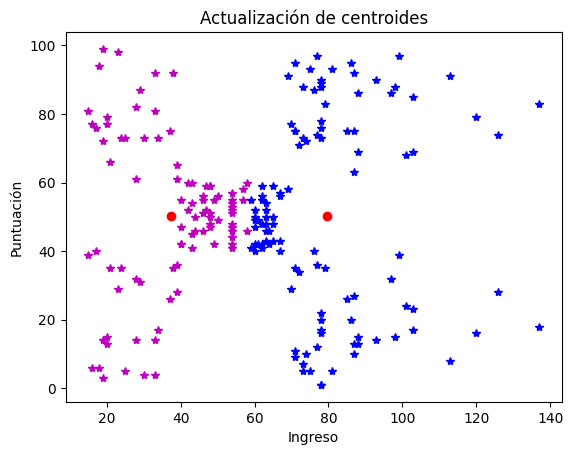

In [ ]:
#Terminando la actualización de manera iterativa
from google.colab import output #Librería para limpiar la salida
import time #Librería para agregar pausa
Ciclos = 20
for t in range(Ciclos):
  output.clear()#Limpio salida
  #1. Etiqueto según distancias a centroides
  Distancias_Centroides=np.zeros((1,k))
  Etiquetas=np.zeros((Fl,1))
  for i in range(Fl):
    for j in range(k):
      Distancias_Centroides[0,j]=np.sqrt(np.sum(np.square(X[i,:]-Centroides[j,:])))
    Pos=np.argmin(Distancias_Centroides[0,0:k])
    Etiquetas[i,0]=Pos

  #2. Graficando los puntos con colores según etiquetas
  Color=["*m","*b","*y","*g","*k","*c","*w"]
  for i in range(Fl):
    for j in range(k):
      if Etiquetas[i,0]==j:
        plt.plot(X[i,0],X[i,1],Color[j])

  plt.plot(Centroides[:,0],Centroides[:,1],'+r')
  plt.xlabel('Ingreso')
  plt.ylabel('Puntuación')
  plt.title('Actualización de centroides')

  #3. Actualizo centroide
  for i in range(k):
    suma=np.zeros((1,Cl))
    cont=0
    for j in range (Fl):
      if Etiquetas[j,0]==i:
        cont=cont+1
        suma=suma+X[j,:]

    Centroides[i,:]=suma[0,:]/cont

  plt.plot(Centroides[:,0],Centroides[:,1],'or')
  plt.show()
  time.sleep(1)


#1. Cargando el conjunto de datos - Clientes

In [ ]:
# @title
from google.colab import files # Librería para activar uso del directorio
import pandas as pd
import time #Librería para incluir pausas
from google.colab import output #Librería para manipular la ventana de resultados
# Cargar una archivo desde tu dispositivo local
Cargador = files.upload()

# Leer archivo con Pandas
for Nombre in Cargador.keys():
    Mis_datos = pd.read_csv(Nombre,sep=',')
    #Mis_datos = pd.read_excel(Nombre)

display(Mis_datos)
time.sleep(5)
output.clear()
print('Dataset cargado correctamente!!')

Dataset cargado correctamente!!


In [ ]:
#Inspeccionando los datos datos
Mis_datos.info()
Mis_datos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Genre                   200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,1.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [ ]:
#Procesando los datos
Mis_datos=Mis_datos.drop(['CustomerID'],axis=1)
Reemplazo={'Male':0,'Female':1}
Mis_datos['Genre']=Mis_datos['Genre'].map(Reemplazo)

#2. Analizando cantidad de grupos

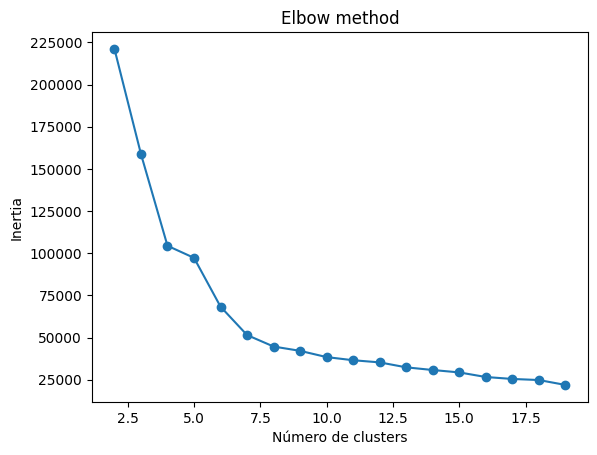

In [ ]:
import matplotlib.pyplot as plt

# @title
#Quitando filas con datos erróneos (En el caso que haya)
Mis_datos = Mis_datos.dropna()
#Convierto los datos a hoja de cálculo
import numpy as np
import time
Datos_Array = np.array(Mis_datos)
# Creando modelo(KMeans es una librería para hacer clustering)
from sklearn.cluster import KMeans
from sklearn import metrics


# Ejecutar KMeans con diferentes números de clusters
inertia_values = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k,n_init = 'auto', random_state=42)
    kmeans.fit(Datos_Array)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(metrics.silhouette_score(Datos_Array, kmeans.labels_))

# Graficar el método del codo
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

print(' ')

#3. Segmentando los datos según un número de grupos "k"

In [ ]:
# @title
k = input('Ingrese la cantidad de grupos:\n')
try:
  k=int(k)
  Modelo_Cluster = KMeans(n_clusters=k, n_init = 'auto', random_state=42)
  Modelo_Cluster.fit(Datos_Array)
  #Segmentando los clientes del dataset
  Etiquetas = Modelo_Cluster.predict(Datos_Array)
  time.sleep(3)
  # Asignando etiqueta como columna nueva al dataset
  Mis_datos2=Mis_datos.copy()
  Mis_datos2['Grupo'] = Etiquetas
  Mis_datos2.head(10)

  #Guardando datos segmentados

  Mis_datos2.to_excel('Datos_Segmentados.xlsx', index=False)
  files.download('Datos_Segmentados.xlsx')

  print('')
  print('Grupos identificados y etiquetados correctamente')
  print('Nuevo archivo de datos descargado correctamente')
except:
  print('El dato ingresado no es número, intenta de nuevo')

Ingrese la cantidad de grupos:
5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Grupos identificados y etiquetados correctamente
Nuevo archivo de datos descargado correctamente


#4. Descargar los patrones de los grupos (centroides)

In [ ]:
# @title
# Obtener los centroides del modelo K-Means
Centroides=Modelo_Cluster.cluster_centers_

# Obtener los nombres de las columnas del dataset original
nombres_variables = Mis_datos.columns[:]  # Excluir la última columna que contiene los clusters

# Crear un DataFrame para los centroides con los nombres de las columnas
Centroides_df = pd.DataFrame(Centroides[:,:] , columns=nombres_variables)


#Descargar los centroides
Centroides_df.to_excel('Patrones_Grupos.xlsx', index=True)
files.download('Patrones_Grupos.xlsx')


# Imprimir los centroides con los nombres de las variables
print("Centroides:")
Centroides_df.head(k)

print('Archivo con datos de Centroides descargado correctamente')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Centroides:
Archivo con datos de Centroides descargado correctamente


#5. Analizando la distribución de los grupos

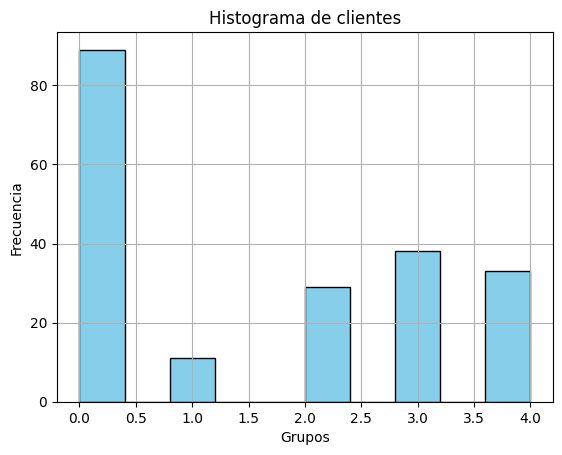

In [ ]:
# @title
# Visualizar los resultados parcialmente (opcional)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Histograma de la variable 'Grupo'
plt.hist(Mis_datos2['Grupo'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Grupos')
plt.ylabel('Frecuencia')
plt.title('Histograma de clientes')
plt.grid(True)
plt.show()

=========================================================

#6. Guardando el modelo entrenado.

In [ ]:
# =====================================
# GUARDAR EL MODELO
# =====================================
import joblib

# Suponiendo que tu modelo entrenado se llama 'modelo'
joblib.dump(Modelo_Cluster, "modelo_Segmentación_entrenado.pkl")
print("Modelo guardado correctamente")

Modelo guardado correctamente


#7. Usando el modelo

In [ ]:
# Cargar el modelo
modelo_cargado = joblib.load("modelo_Segmentación_entrenado.pkl")

# Pedir entradas al usuario (ajusta según tus variables de entrada)
# Ejemplo con 4 variables de entrada
n1 = float(input("Ingrese el género (1 hombre, 2 mujer): "))
n2 = float(input("Ingrese la edad: "))
n3 = float(input("Ingrese el Income (15000-135000 ): "))
n4 = float(input("Ingrese el puntaje (1 - 100): "))

# Crear arreglo con los nuevos datos
nuevos_datos = [[n1, n2, n3, n4]]

# Hacer la predicción
prediccion = modelo_cargado.predict(nuevos_datos)
print("La predicción para los datos ingresados es:", prediccion)

Ingrese el género (1 hombre, 2 mujer): 1
Ingrese la edad: 36
Ingrese el Income: 1200
Ingrese el puntaje (1 - 100): 70
La predicción para los datos ingresados es: [1]
